Zadanie 1 - Wizualizacja metody gradientu z użyciem tensorflow

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

In [2]:
# funkcja celu
def target_fn(x, y):
    return x**2 - tf.exp(-(x + 3*y))

# start - punkt
x = tf.Variable(5.0)
y = tf.Variable(5.0)

# optymalizacja - parametry
learning_rate = 0.1
optimizer = tf.keras.optimizers.SGD(learning_rate)

# przebieg optymalizacji - historia
x_history = []
y_history = []
f_history = []

In [3]:
with tf.GradientTape() as tape:
    value = target_fn(x, y)

gradients = tape.gradient(value, [x, y])

print("Gradient względem x:", gradients[0].numpy())
print("Gradient względem y:", gradients[1].numpy())

Gradient względem x: 10.0
Gradient względem y: 6.183461e-09


In [4]:
epochs = 100

for i in range(epochs):

    with tf.GradientTape() as tape:
        value = target_fn(x, y)

    gradients = tape.gradient(value, [x, y])

    optimizer.apply_gradients(zip(gradients, [x, y]))

    x_history.append(x.numpy())
    y_history.append(y.numpy())
    f_history.append(value.numpy())

    if i % 10 == 0:
        print(
            f"Iteracja {i}: "
            f"x={x.numpy():.4f}, "
            f"y={y.numpy():.4f}, "
            f"f={value.numpy():.4f}"
        )

print("\nWynik końcowy:")
print("x =", x.numpy())
print("y =", y.numpy())
print("f(x,y) =", target_fn(x, y).numpy())

Iteracja 0: x=4.0000, y=5.0000, f=25.0000
Iteracja 10: x=0.4295, y=5.0000, f=0.2882
Iteracja 20: x=0.0461, y=5.0000, f=0.0033
Iteracja 30: x=0.0050, y=5.0000, f=0.0000
Iteracja 40: x=0.0005, y=5.0000, f=0.0000
Iteracja 50: x=0.0001, y=5.0000, f=-0.0000
Iteracja 60: x=0.0000, y=5.0000, f=-0.0000
Iteracja 70: x=0.0000, y=5.0000, f=-0.0000
Iteracja 80: x=-0.0000, y=5.0000, f=-0.0000
Iteracja 90: x=-0.0000, y=5.0000, f=-0.0000

Wynik końcowy:
x = -1.5193264e-07
y = 5.0
f(x,y) = -3.059023e-07


In [5]:
x_grid = np.linspace(1, 10, 100)
y_grid = np.linspace(1, 10, 100)

X, Y = np.meshgrid(x_grid, y_grid)

Z = X**2 - np.exp(-(X + 3*Y))

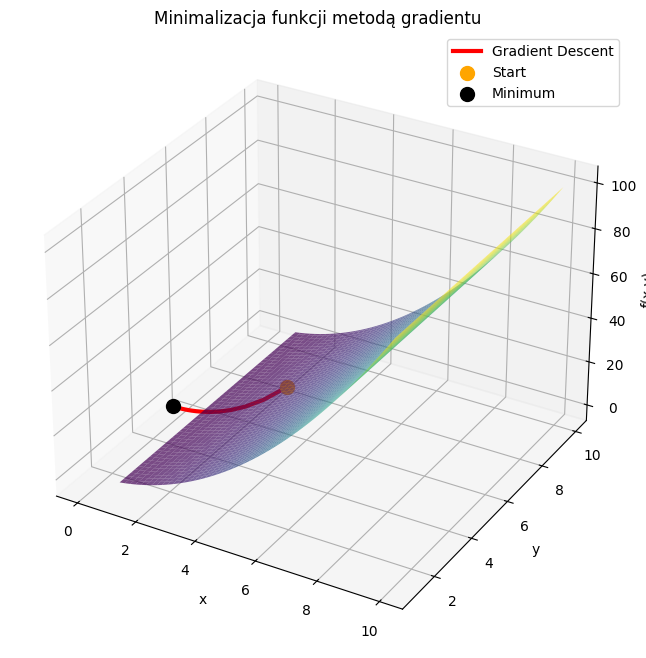

In [6]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# powierzchnia funkcji
ax.plot_surface(
    X,
    Y,
    Z,
    cmap='viridis',
    alpha=0.7
)

# ścieżka gradientu
ax.plot(
    x_history,
    y_history,
    f_history,
    color='red',
    linewidth=3,
    label='Gradient Descent'
)

# punkt startowy
ax.scatter(
    x_history[0],
    y_history[0],
    f_history[0],
    color='orange',
    s=100,
    label='Start'
)

# punkt końcowy
ax.scatter(
    x_history[-1],
    y_history[-1],
    f_history[-1],
    color='black',
    s=100,
    label='Minimum'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')

ax.set_title('Minimalizacja funkcji metodą gradientu')
ax.legend()

plt.show()

In [ ]:
Zadanie 2 - Implementacja – gradienty sieci neuronowej z NumPy

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
nn_architecture = [
    {"input_dim": 2, "output_dim": 2, "activation": "elu"},
    {"input_dim": 2, "output_dim": 1, "activation": "elu"}
]

In [9]:
def init_layers(nn_architecture, seed=99):

    np.random.seed(seed)

    params_values = {}

    for idx, layer in enumerate(nn_architecture):

        layer_idx = idx + 1

        input_size = layer["input_dim"]
        output_size = layer["output_dim"]

        params_values["W" + str(layer_idx)] = (
            np.random.randn(output_size, input_size) * 0.1
        )

        params_values["b" + str(layer_idx)] = (
            np.random.randn(output_size, 1) * 0.1
        )

    return params_values

In [10]:
def elu(Z, alpha=1.0):
    return np.where(Z > 0, Z, alpha * (np.exp(Z) - 1))


def elu_backward(dA, Z, alpha=1.0):

    derivative = np.where(
        Z > 0,
        1,
        alpha * np.exp(Z)
    )

    return dA * derivative

In [11]:
def single_layer_forward_propagation(
        A_prev,
        W_curr,
        b_curr,
        activation="elu"
):

    Z_curr = np.dot(W_curr, A_prev) + b_curr

    if activation == "elu":
        A_curr = elu(Z_curr)
    else:
        raise Exception("Nieobsługiwana funkcja aktywacji")

    return A_curr, Z_curr

In [12]:
def full_forward_propagation(
        X,
        params_values,
        nn_architecture
):

    memory = {}

    A_curr = X

    for idx, layer in enumerate(nn_architecture):

        layer_idx = idx + 1

        A_prev = A_curr

        A_curr, Z_curr = single_layer_forward_propagation(
            A_prev,
            params_values["W" + str(layer_idx)],
            params_values["b" + str(layer_idx)],
            layer["activation"]
        )

        memory["A" + str(idx)] = A_prev
        memory["Z" + str(layer_idx)] = Z_curr

    return A_curr, memory

In [13]:
def get_cost_value(Y_hat, Y):

    m = Y.shape[1]

    cost = np.sum((Y_hat - Y) ** 2) / m

    return cost

In [14]:
def single_layer_backward_propagation(
        dA_curr,
        W_curr,
        Z_curr,
        A_prev,
        activation="elu"
):

    m = A_prev.shape[1]

    if activation == "elu":
        dZ_curr = elu_backward(dA_curr, Z_curr)
    else:
        raise Exception("Nieobsługiwana funkcja aktywacji")

    dW_curr = np.dot(dZ_curr, A_prev.T) / m

    db_curr = np.sum(
        dZ_curr,
        axis=1,
        keepdims=True
    ) / m

    dA_prev = np.dot(
        W_curr.T,
        dZ_curr
    )

    return dA_prev, dW_curr, db_curr

In [15]:
def full_backward_propagation(
        Y_hat,
        Y,
        memory,
        params_values,
        nn_architecture
):

    grads_values = {}

    dA_prev = 2 * (Y_hat - Y)

    for layer_idx_prev, layer in reversed(
            list(enumerate(nn_architecture))
    ):

        layer_idx_curr = layer_idx_prev + 1

        dA_curr = dA_prev

        A_prev = memory["A" + str(layer_idx_prev)]
        Z_curr = memory["Z" + str(layer_idx_curr)]

        W_curr = params_values["W" + str(layer_idx_curr)]

        dA_prev, dW_curr, db_curr = \
            single_layer_backward_propagation(
                dA_curr,
                W_curr,
                Z_curr,
                A_prev,
                layer["activation"]
            )

        grads_values["dW" + str(layer_idx_curr)] = dW_curr
        grads_values["db" + str(layer_idx_curr)] = db_curr

    return grads_values

In [16]:
def update(
        params_values,
        grads_values,
        nn_architecture,
        learning_rate
):

    for idx, layer in enumerate(nn_architecture):

        layer_idx = idx + 1

        params_values["W" + str(layer_idx)] -= (
            learning_rate *
            grads_values["dW" + str(layer_idx)]
        )

        params_values["b" + str(layer_idx)] -= (
            learning_rate *
            grads_values["db" + str(layer_idx)]
        )

    return params_values

In [17]:
def train(
        X,
        Y,
        nn_architecture,
        epochs,
        learning_rate
):

    params_values = init_layers(nn_architecture)

    cost_history = []

    for i in range(epochs):

        Y_hat, memory = full_forward_propagation(
            X,
            params_values,
            nn_architecture
        )

        cost = get_cost_value(Y_hat, Y)

        cost_history.append(cost)

        grads_values = full_backward_propagation(
            Y_hat,
            Y,
            memory,
            params_values,
            nn_architecture
        )

        params_values = update(
            params_values,
            grads_values,
            nn_architecture,
            learning_rate
        )

    return params_values, cost_history

In [18]:
X = np.array([
    [0.2, 0.5, 0.8, 1.0],
    [0.1, 0.4, 0.6, 0.9]
])

Y = np.array([
    [0.3, 0.7, 1.0, 1.2]
])

In [19]:
params, cost_history = train(
    X,
    Y,
    nn_architecture,
    epochs=1000,
    learning_rate=0.01
)

print("Uczenie zakończone.")

for key, value in params.items():
    print(f"\n{key}")
    print(value)

Uczenie zakończone.

W1
[[0.32704743 0.52967331]
 [0.37025875 0.45706539]]

b1
[[-0.07085   ]
 [-0.05588753]]

W2
[[0.59621839 0.58083454]]

b2
[[0.33603775]]


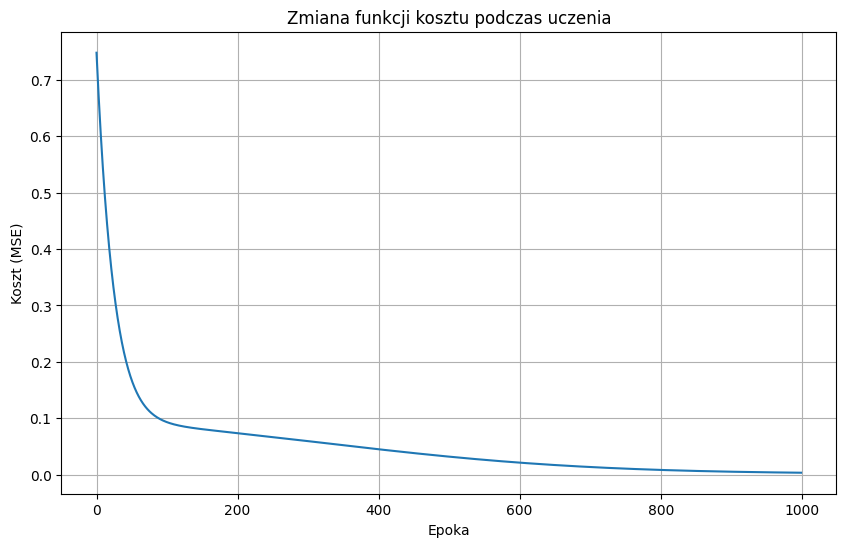

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(cost_history)

plt.title("Zmiana funkcji kosztu podczas uczenia")
plt.xlabel("Epoka")
plt.ylabel("Koszt (MSE)")

plt.grid(True)

plt.show()